## **Feature Importance: Decision Tree and Random Forest**

### **Topic Roadmap**

**1. Prepare a classification dataset**

**2. Compare impurity importance**

**3. Measure permutation importance**

**4. Visualize the rankings**

**5. Key revision notes**

## **1. Dataset and Models**

This notebook compares two tree-based importance estimates on an unseen test split.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

data = load_breast_cancer(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, stratify=data.target, random_state=42
)
tree = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
forest = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1).fit(X_train, y_train)

## **2. Impurity-Based Importance**

Each fitted tree exposes the total impurity reduction attributed to each feature. The values are normalized to sum to one.

In [6]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "decision_tree": tree.feature_importances_,
    "random_forest": forest.feature_importances_,
}).set_index("feature")
importance_df.sort_values("random_forest", ascending=False).head(10)

,decision_tree,random_forest
feature,,
worst perimeter,0.000000,0.136873
worst area,0.008652,0.129510
worst concave points,0.118831,0.112920
worst radius,0.714332,0.091390
mean concave points,0.000000,0.090736
mean radius,0.000000,0.057109
mean perimeter,0.006409,0.054021
mean concavity,0.000000,0.045544
mean area,0.000000,0.043285


## **3. Permutation Importance**

Permutation importance measures the decrease in test score after randomly shuffling one feature. It is model- and metric-dependent.

In [7]:
permutation = permutation_importance(
    forest, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1
)
permutation_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean": permutation.importances_mean,
    "std": permutation.importances_std,
}).sort_values("mean", ascending=False)
permutation_df.head(10)

,feature,mean,std
7,mean concave points,0.000585,0.002188
0,mean radius,0.000000,0.000000
9,mean fractal dimension,0.000000,0.000000
10,radius error,0.000000,0.000000
3,mean area,0.000000,0.000000
15,compactness error,0.000000,0.000000
18,symmetry error,0.000000,0.000000
17,concave points error,0.000000,0.000000
29,worst fractal dimension,0.000000,0.000000
19,fractal dimension error,0.000000,0.000000


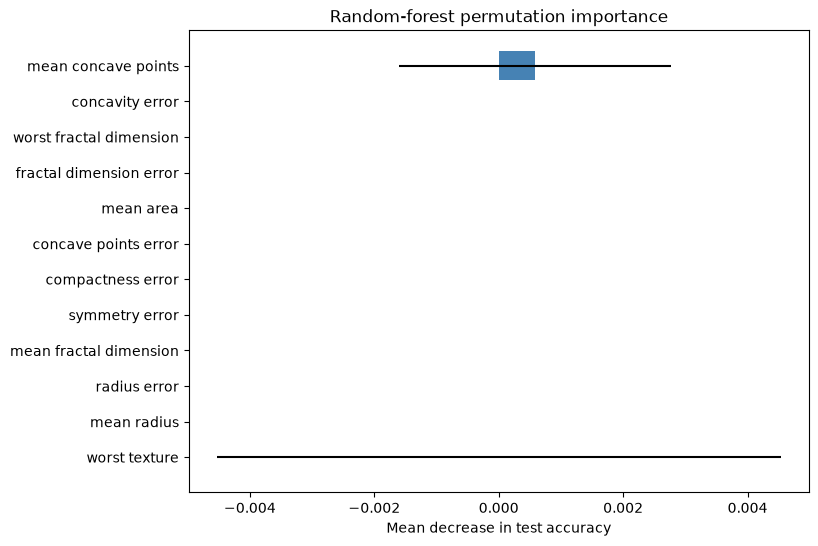

In [8]:
plot_df = permutation_df.head(12).sort_values("mean")
plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["mean"], xerr=plot_df["std"], color="steelblue")
plt.xlabel("Mean decrease in test accuracy")
plt.title("Random-forest permutation importance")
plt.show()

### **Key Revision Notes**

- Impurity importance is quick but can be biased by feature scale/cardinality and correlated features.
- Permutation importance is measured on a chosen dataset and metric.
- Correlated features can share or mask importance.
- Importance is not causal evidence; it is a model-behavior diagnostic.